In [59]:
from pathlib import Path
import argparse
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score



def target_in_txtdir(txt_dir: Path, targetid: np.int64):
    results = []
    for txt_path in sorted(txt_dir.glob('*.txt')):
        try:
            with open(txt_path, 'r') as f:
                lines = f.readlines()
            start = 1 if lines and (',' in lines[0] and not lines[0].split(',')[0].strip().isdigit()) else 0
            for l in lines[start:]:
                if not l.strip():
                    continue
                token = l.split(',')[0].strip()
                try:
                    t = np.int64(int(token))
                except Exception:
                    continue
                if t == targetid:
                    results.append(txt_path.name)
                    break
        except Exception as e:
            raise RuntimeError(f'Error reading {txt_path}: {e}')
    return results

def find_id(targetid, txt_dir='/pscratch/sd/v/vtorresg/umap_analysis/data/text_files', ):

    found_in = target_in_txtdir(Path(txt_dir), targetid)
    if not found_in:
        print(f'result=NOT_FOUND targetid={targetid}')
    else:
        print(f'result=FOUND targetid={targetid} files={",".join(found_in)}')


In [5]:
#these are the first two mentioned in this issue https://github.com/desihub/desispec/issues/2548
find_id(39633474352580720)
find_id(39628272476095749)
find_id(39627859727221405)
find_id(23058430288933725558)

result=FOUND targetid=39633474352580720 files=20240321_27588.txt
result=FOUND targetid=39628272476095749 files=20240227_21413.txt
result=NOT_FOUND targetid=39627859727221405
result=NOT_FOUND targetid=23058430288933725558


In [7]:
#these are the first two mentioned 
find_id(39633014778495629)
find_id(39633460310051122)


result=NOT_FOUND targetid=39633014778495629
result=NOT_FOUND targetid=39633460310051122


In [51]:
DEFAULT_TILES = (
    "/pscratch/sd/v/vtorresg/umap_analysis/data/processed/umap/umap_20231214_26024.npz",
    "/pscratch/sd/v/vtorresg/umap_analysis/data/processed/umap/umap_20210331_80652.npz",
)

GOOD_OUTLIER = (39633460310051122, 39633014778495629)


[[ -8.203458  -12.451309 ]
 [  1.3396958 -12.993336 ]
 [  3.2308688 -10.006633 ]
 ...
 [ -7.7570305  -7.1871486]
 [  1.788857  -14.941123 ]
 [  1.4900486 -14.577613 ]]
[False False False ... False False False]
Number of outliers detected: 0
Number of inliers: 4148

Outlier indices: []
ids []

Novelty scores (min=0.006, max=0.561)
Original outlier score [0.41072667 0.11246324 0.45403957 0.42749906 0.32334626 0.43257523
 0.37395978 0.41198957 0.4382577  0.21171641 0.41572785 0.42747712
 0.49773693 0.44241643 0.3921305  0.38183188 0.39523315 0.39294064
 0.3940338  0.44988322 0.2708043  0.4876598  0.38971055 0.39625287
 0.44522023 0.3977599  0.46697438 0.44309747 0.47413385 0.45049548
 0.24856496 0.44422626 0.43792677 0.00569749 0.46343315 0.39599812
 0.41041136 0.37463796 0.45801485 0.47180593 0.39762676 0.46470428
 0.3438617  0.48574328 0.44163704 0.41450477 0.469774   0.31635273
 0.3601923  0.44063938 0.46121716 0.43622673 0.35042346 0.36009824
 0.38780367 0.38884437 0.44785333 0.373124

(array([ 1.,  1.,  1.,  3.,  8., 12., 17., 33., 42., 24.]),
 array([0.00569749, 0.05490143, 0.10410538, 0.15330932, 0.20251326,
        0.25171721, 0.30092114, 0.3501251 , 0.39932904, 0.448533  ,
        0.49773693]),
 <BarContainer object of 10 artists>)

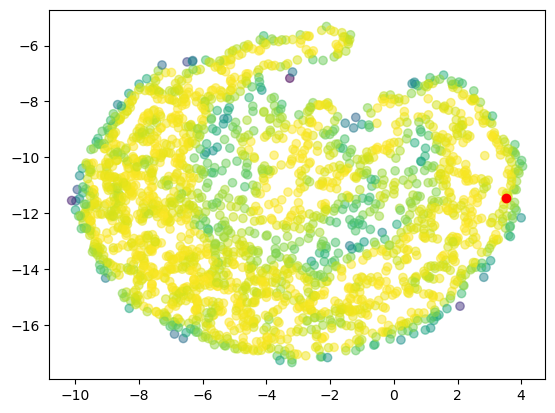

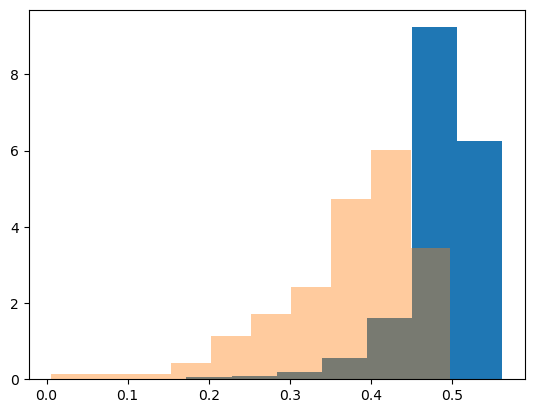

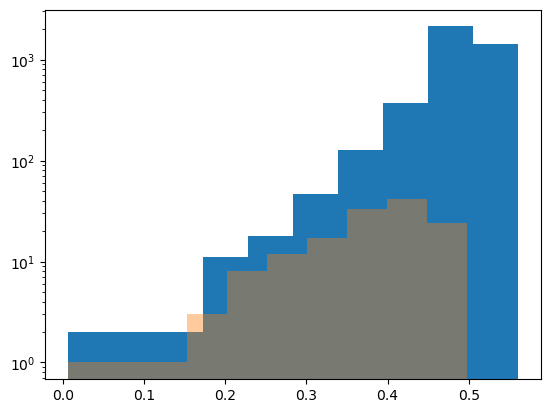

In [105]:
tile_id = 0
data = np.load(DEFAULT_TILES[tile_id], allow_pickle=True)
embedding = data["embedding"]
ids = data["ids"]
outlier_mask = data["outlier_mask"]
print(embedding)
print(outlier_mask)


# Your embedding array
# embedding = np.array([...])  # your data here

# Create LOF model for novelty detection
clf = LocalOutlierFactor(n_neighbors=20, novelty=True)

# Fit the model on your data
clf.fit(embedding)

# Predict on the same data (or new data)
# Returns -1 for outliers/novelties, 1 for inliers
y_pred = clf.predict(embedding)

# Get novelty scores (negative scores are outliers)
# More negative = more anomalous
scores = clf.decision_function(embedding)

# Print results
print(f"Number of outliers detected: {(y_pred == -1).sum()}")
print(f"Number of inliers: {(y_pred == 1).sum()}")
print(f"\nOutlier indices: {np.where(y_pred == -1)[0]}")
print(f"ids {ids[y_pred==-1]}")
print(f"\nNovelty scores (min={scores.min():.3f}, max={scores.max():.3f})")
print(f"Original outlier score {scores[outlier_mask]}")

outlier_id = GOOD_OUTLIER[tile_id]
jj = ids==outlier_id
print('good outlier score', scores[jj])
ii = scores<0.5
kk = y_pred==-1
plt.scatter(embedding[ii,0], embedding[ii,1], c=scores[ii], alpha=0.5)
plt.scatter(embedding[jj,0], embedding[jj,1], c='red')
plt.scatter(embedding[kk,0], embedding[kk,1], marker='*',c='black', s=100)


# Convert LOF predictions to boolean (True = outlier)
lof_outliers = (y_pred == -1)
plt.figure()
plt.hist(scores, density=True)
plt.hist(scores[outlier_mask], density=True, alpha=0.4)

plt.figure()
plt.hist(scores, log=True)
plt.hist(scores[outlier_mask], log=True, alpha=0.4)

In [106]:
np.median(scores)

0.49683672